# Analisis Time Series Harga ETH dengan ARIMA

Notebook ini menganalisis harga ETH dalam rentang waktu pendek menggunakan model ARIMA. Fokus analisisnya adalah membuat alur yang reproducible, mengecek stasioneritas, memilih model tanpa data leakage, dan mengevaluasi forecast pada data test.


## 1. Setup dan Load Data

Data dibaca dari `ETH.xlsx`. File ini harus berada di folder yang sama dengan notebook agar analisis bisa dijalankan ulang.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import shapiro
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller


In [2]:
DATA_PATH = "ETH.xlsx"
TIME_COL = "t"
TARGET_COL = "harga_ETH"

data = pd.read_excel(DATA_PATH)

expected_cols = {TIME_COL, TARGET_COL}
missing_cols = expected_cols.difference(data.columns)
if missing_cols:
    raise ValueError(f"Kolom wajib tidak ditemukan: {missing_cols}")

data[TIME_COL] = pd.to_datetime(data[TIME_COL])
data = data.sort_values(TIME_COL).set_index(TIME_COL)
data = data[[TARGET_COL]].dropna()

print(f"Jumlah observasi: {len(data)}")
print(f"Periode data: {data.index.min()} sampai {data.index.max()}")
print(f"Missing value: {data[TARGET_COL].isna().sum()}")
data.head()


Jumlah observasi: 119
Periode data: 2025-10-21 01:22:38 sampai 2025-10-21 02:11:57
Missing value: 0


,harga_ETH
t,
2025-10-21 01:22:38,3948.61
2025-10-21 01:23:03,3949.76
2025-10-21 01:23:28,3949.60
2025-10-21 01:23:53,3951.30
2025-10-21 01:24:18,3949.48


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 119 entries, 2025-10-21 01:22:38 to 2025-10-21 02:11:57
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   harga_ETH  119 non-null    float64
dtypes: float64(1)
memory usage: 1.9 KB


## 2. Eksplorasi Awal

Plot harga digunakan untuk melihat pola umum, trend pendek, dan volatilitas. Karena data ETH ini berfrekuensi sangat pendek, hasil model perlu dibaca sebagai eksperimen time series jangka pendek, bukan model produksi untuk trading.


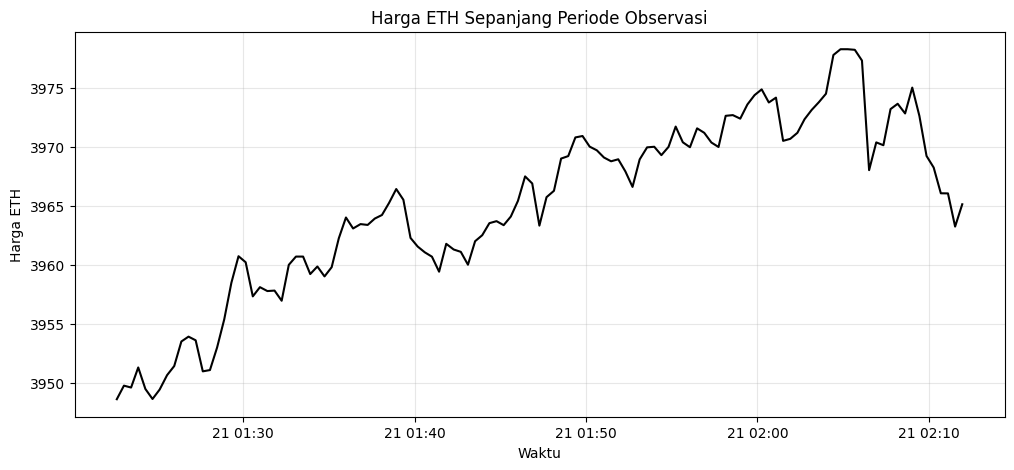

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(data[TARGET_COL], color="black")
plt.title("Harga ETH Sepanjang Periode Observasi")
plt.xlabel("Waktu")
plt.ylabel("Harga ETH")
plt.grid(True, alpha=0.3)
plt.show()


In [5]:
data[TARGET_COL].describe()


count     119.000000
mean     3964.984874
std         7.508093
min      3948.610000
25%      3960.445000
50%      3965.720000
75%      3970.430000
max      3978.250000
Name: harga_ETH, dtype: float64

## 3. Uji Stasioneritas

ARIMA membutuhkan seri yang stasioner setelah differencing. Uji ADF dilakukan pada harga asli, data training, dan log-difference training.


In [6]:
def adf_report(series, label):
    result = adfuller(series.dropna())
    return pd.Series({
        "series": label,
        "adf_statistic": result[0],
        "p_value": result[1],
        "is_stationary_5pct": result[1] < 0.05,
    })

y = data[TARGET_COL]

adf_full = adf_report(y, "Harga ETH - full data")
adf_full.to_frame().T


,series,adf_statistic,p_value,is_stationary_5pct
0,Harga ETH - full data,-2.233473,0.194322,False


## 4. Train-Test Split

Split dilakukan secara kronologis 80:20. Data test hanya dipakai untuk evaluasi final, bukan untuk memilih model.


In [7]:
train_size = int(len(y) * 0.8)
train = y.iloc[:train_size]
test = y.iloc[train_size:]

print(f"Train: {len(train)} observasi, {train.index.min()} sampai {train.index.max()}")
print(f"Test : {len(test)} observasi, {test.index.min()} sampai {test.index.max()}")


Train: 95 observasi, 2025-10-21 01:22:38 sampai 2025-10-21 02:01:55
Test : 24 observasi, 2025-10-21 02:02:20 sampai 2025-10-21 02:11:57


In [8]:
adf_train = adf_report(train, "Harga ETH - train")
log_diff_train = np.log(train).diff().dropna()
adf_log_diff = adf_report(log_diff_train, "Log-difference ETH - train")

pd.DataFrame([adf_train, adf_log_diff])


,series,adf_statistic,p_value,is_stationary_5pct
0,Harga ETH - train,-1.878769,0.342114,False
1,Log-difference ETH - train,-3.512247,0.007678,True


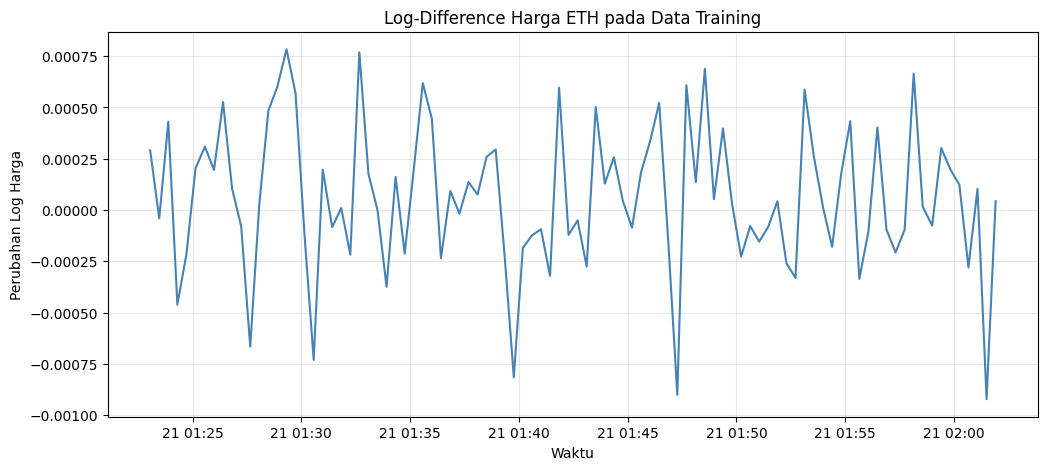

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(log_diff_train, color="steelblue")
plt.title("Log-Difference Harga ETH pada Data Training")
plt.xlabel("Waktu")
plt.ylabel("Perubahan Log Harga")
plt.grid(True, alpha=0.3)
plt.show()


## 5. ACF dan PACF

ACF dan PACF pada log-difference training membantu memberi gambaran awal kandidat orde ARIMA. Kandidat model tetap dibatasi karena jumlah observasi kecil.


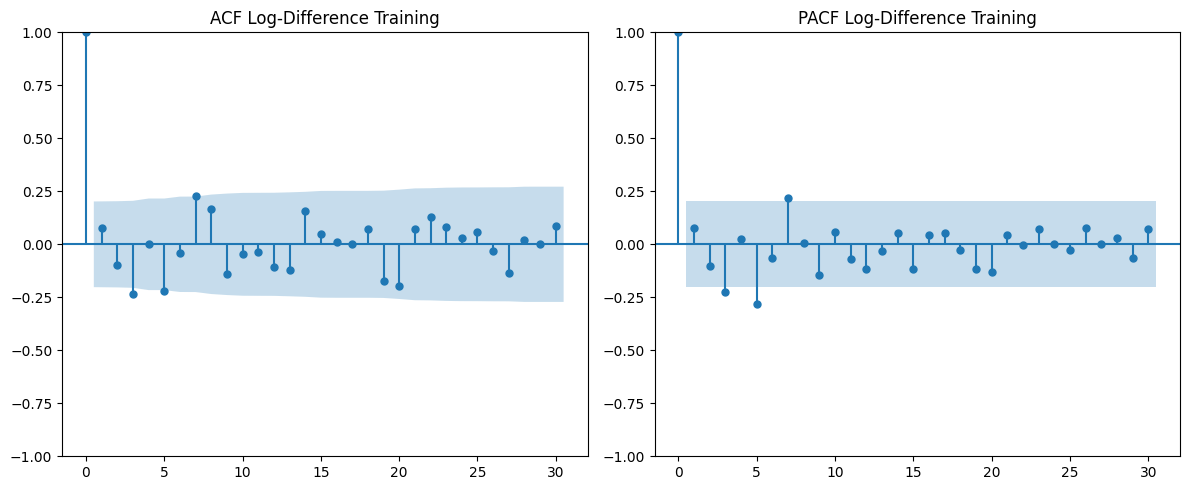

In [10]:
max_lag = min(30, max(1, len(log_diff_train) // 2 - 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(log_diff_train, lags=max_lag, ax=axes[0])
axes[0].set_title("ACF Log-Difference Training")
plot_pacf(log_diff_train, lags=max_lag, ax=axes[1], method="ywm")
axes[1].set_title("PACF Log-Difference Training")
plt.tight_layout()
plt.show()


## 6. Pemilihan Model ARIMA

Grid search dibatasi pada `p` dan `q` 0 sampai 3 dengan `d=1`. Pemilihan dilakukan hanya pada data training untuk mencegah leakage. Metric forecast dihitung dari validation window terakhir di training.


In [11]:
def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_forecast(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mape_pct": safe_mape(y_true, y_pred),
    }


def fit_and_eval_order(order, train_series, validation_steps=20):
    result = {"order": order}
    try:
        fitted_full = ARIMA(train_series, order=order).fit()
        result["aic"] = fitted_full.aic
        result["bic"] = fitted_full.bic

        lb_lag = min(10, max(1, len(fitted_full.resid.dropna()) // 5))
        lb = acorr_ljungbox(fitted_full.resid.dropna(), lags=[lb_lag], return_df=True)
        result["ljungbox_lag"] = lb_lag
        result["ljungbox_pvalue"] = lb["lb_pvalue"].iloc[0]

        if len(train_series) > validation_steps + 10:
            inner_train = train_series.iloc[:-validation_steps]
            validation = train_series.iloc[-validation_steps:]
            fitted_inner = ARIMA(inner_train, order=order).fit()
            forecast = fitted_inner.forecast(steps=len(validation))
            result.update(evaluate_forecast(validation, forecast))
        else:
            result.update({"mae": np.nan, "rmse": np.nan, "mape_pct": np.nan})
    except Exception as exc:
        result["error"] = str(exc)
    return result


In [12]:
orders = [(p, 1, q) for p in range(4) for q in range(4) if not (p == 0 and q == 0)]
validation_steps = min(20, max(5, len(train) // 5))
results = [fit_and_eval_order(order, train, validation_steps=validation_steps) for order in orders]

summary_df = pd.DataFrame(results)
if "error" in summary_df.columns:
    summary_df = summary_df[summary_df["error"].isna()].copy()

summary_df.sort_values(["bic", "rmse"]).reset_index(drop=True)


c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been

,order,aic,bic,ljungbox_lag,ljungbox_pvalue,mae,rmse,mape_pct
0,"(2, 1, 2)",327.901550,340.618024,10,1.0,2.351308,2.853916,0.059183
1,"(0, 1, 1)",335.565826,340.652416,10,1.0,1.874618,2.463659,0.047182
2,"(1, 1, 0)",335.668256,340.754846,10,1.0,1.865256,2.451980,0.046946
3,"(0, 1, 3)",331.525264,341.698443,10,1.0,2.712847,3.184836,0.068285
4,"(2, 1, 3)",328.773317,344.033085,10,1.0,2.585554,3.067923,0.065081
5,"(1, 1, 3)",331.827896,344.544370,10,1.0,2.612261,3.098202,0.065753
6,"(2, 1, 0)",337.095622,344.725506,10,1.0,1.925111,2.508910,0.048453
7,"(0, 1, 2)",337.519944,345.149829,10,1.0,1.877657,2.466912,0.047258
8,"(1, 1, 1)",337.557721,345.187605,10,1.0,1.873141,2.461785,0.047144
9,"(3, 1, 0)",335.563544,345.736723,10,1.0,2.580168,3.075192,0.064945


In [13]:
best_by_bic = summary_df.sort_values(["bic", "rmse"]).iloc[0]
best_order = tuple(best_by_bic["order"])

print(f"Model terpilih berdasarkan BIC: ARIMA{best_order}")
best_by_bic


Model terpilih berdasarkan BIC: ARIMA(2, 1, 2)


order               (2, 1, 2)
aic                 327.90155
bic                340.618024
ljungbox_lag               10
ljungbox_pvalue           1.0
mae                  2.351308
rmse                 2.853916
mape_pct             0.059183
Name: 9, dtype: object

## 7. Fit Model Final dan Diagnostic Residual

Model final di-fit pada data training. Diagnostic residual digunakan untuk mengecek autokorelasi, normalitas, dan indikasi heteroskedastisitas. Normalitas residual bukan syarat utama forecast ARIMA, tetapi tetap berguna sebagai informasi.


In [14]:
final_model = ARIMA(train, order=best_order)
final_fit = final_model.fit()
print(final_fit.summary())


c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              harga_ETH   No. Observations:                   95
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -158.951
Date:                Mon, 18 May 2026   AIC                            327.902
Time:                        09:20:10   BIC                            340.618
Sample:                             0   HQIC                           333.038
                                 - 95                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5445      0.112     -4.879      0.000      -0.763      -0.326
ar.L2         -0.7860      0.092     -8.548      0.000      -0.966      -0.606
ma.L1          0.8138      1.850      0.440      0.6

c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [15]:
residuals = final_fit.resid.dropna()
residuals = residuals.iloc[1:] if len(residuals) > 1 else residuals

lb_lag = min(10, max(1, len(residuals) // 5))
ljungbox_result = acorr_ljungbox(residuals, lags=[lb_lag], return_df=True)
shapiro_stat, shapiro_pvalue = shapiro(residuals)
arch_stat, arch_pvalue, arch_f_stat, arch_f_pvalue = het_arch(residuals)

diagnostic_df = pd.DataFrame({
    "test": ["Ljung-Box", "Shapiro-Wilk", "ARCH LM", "ARCH F"],
    "statistic": [ljungbox_result["lb_stat"].iloc[0], shapiro_stat, arch_stat, arch_f_stat],
    "p_value": [ljungbox_result["lb_pvalue"].iloc[0], shapiro_pvalue, arch_pvalue, arch_f_pvalue],
    "note": [
        f"Lag {lb_lag}; p > 0.05 berarti tidak ada autokorelasi residual yang kuat",
        "p > 0.05 berarti residual mendekati normal",
        "p > 0.05 berarti tidak ada indikasi ARCH yang kuat",
        "p > 0.05 berarti tidak ada indikasi ARCH yang kuat",
    ],
})

diagnostic_df


,test,statistic,p_value,note
0,Ljung-Box,13.036758,0.221624,Lag 10; p > 0.05 berarti tidak ada autokorelas...
1,Shapiro-Wilk,0.977581,0.106135,p > 0.05 berarti residual mendekati normal
2,ARCH LM,4.167640,0.939468,p > 0.05 berarti tidak ada indikasi ARCH yang ...
3,ARCH F,0.381096,0.951106,p > 0.05 berarti tidak ada indikasi ARCH yang ...


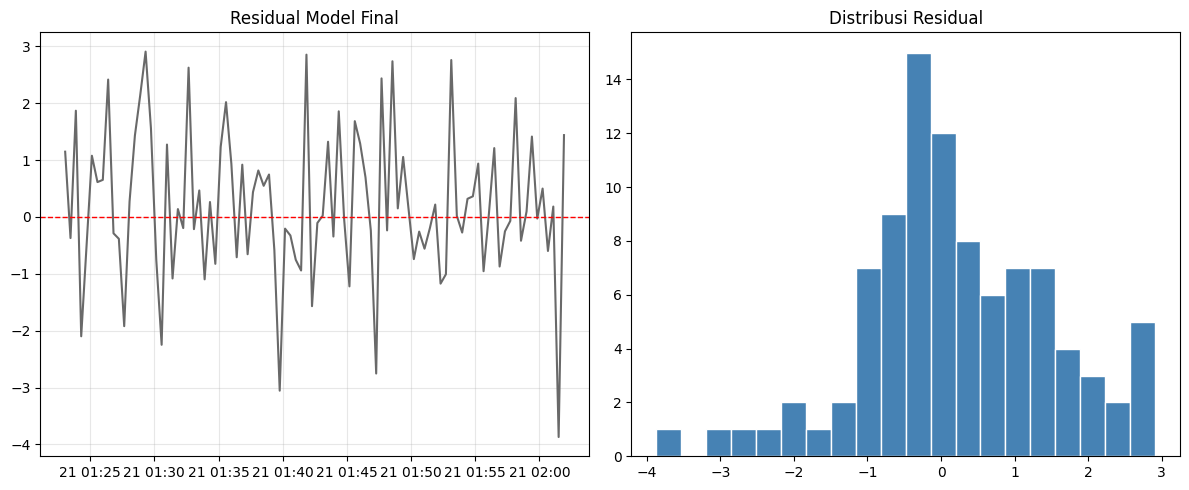

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(residuals, color="dimgray")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Residual Model Final")
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=20, color="steelblue", edgecolor="white")
axes[1].set_title("Distribusi Residual")
plt.tight_layout()
plt.show()


## 8. Evaluasi Forecast pada Data Test

Evaluasi final dilakukan dengan model yang di-fit pada data training, lalu forecast sepanjang horizon data test. Ini adalah evaluasi out-of-sample.


In [17]:
test_forecast = final_fit.forecast(steps=len(test))
test_forecast.index = test.index

test_metrics = evaluate_forecast(test, test_forecast)
train_fitted = final_fit.fittedvalues.reindex(train.index)
train_metrics = evaluate_forecast(train.iloc[1:], train_fitted.iloc[1:])

metrics_df = pd.DataFrame([
    {"dataset": "train_in_sample", **train_metrics},
    {"dataset": "test_out_of_sample", **test_metrics},
])
metrics_df


c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,dataset,mae,rmse,mape_pct
0,train_in_sample,0.993573,1.313742,0.025075
1,test_out_of_sample,3.665929,4.358967,0.092288


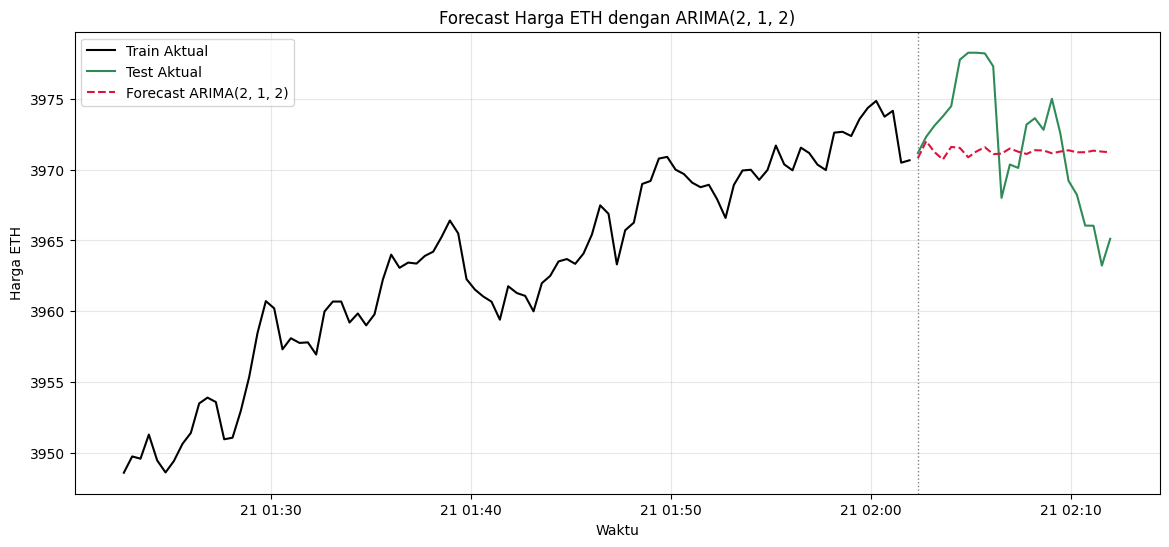

In [18]:
plt.figure(figsize=(14, 6))
plt.plot(train, label="Train Aktual", color="black")
plt.plot(test, label="Test Aktual", color="seagreen")
plt.plot(test_forecast, label=f"Forecast ARIMA{best_order}", color="crimson", linestyle="--")
plt.axvline(test.index[0], color="gray", linestyle=":", linewidth=1)
plt.title(f"Forecast Harga ETH dengan ARIMA{best_order}")
plt.xlabel("Waktu")
plt.ylabel("Harga ETH")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [19]:
comparison_df = pd.DataFrame({
    "actual": test,
    "forecast": test_forecast,
})
comparison_df["error"] = comparison_df["actual"] - comparison_df["forecast"]
comparison_df.head(10)


,actual,forecast,error
t,,,
2025-10-21 02:02:20,3971.17,3970.809532,0.360468
2025-10-21 02:02:45,3972.32,3972.006556,0.313444
2025-10-21 02:03:10,3973.11,3971.237249,1.872751
2025-10-21 02:03:35,3973.76,3970.715277,3.044723
2025-10-21 02:04:00,3974.48,3971.604162,2.875838
2025-10-21 02:04:26,3977.76,3971.530435,6.229565
2025-10-21 02:04:51,3978.25,3970.871918,7.378082
2025-10-21 02:05:16,3978.25,3971.288427,6.961573
2025-10-21 02:05:41,3978.20,3971.579232,6.620768


## 9. Kesimpulan dan Batasan

- Data ETH pada notebook ini memiliki 119 observasi dalam rentang sekitar 50 menit, sehingga hasil model hanya merepresentasikan pola jangka sangat pendek.
- Harga asli tidak stasioner pada uji ADF, sedangkan log-difference training lebih stasioner. Karena itu model ARIMA menggunakan `d=1`.
- Pemilihan model dilakukan hanya menggunakan data training untuk menghindari data leakage.
- Evaluasi final menggunakan forecast out-of-sample pada data test.
- Karena sampel kecil dan harga crypto sangat volatil, model ini lebih cocok sebagai demonstrasi workflow time series daripada sistem prediksi harga real-time.
